## Setup (imports, deps, compile pointnet2)

In [2]:
# ============================================
# Cell 1 — Setup: deps + pointnet2 compile
# ============================================
import os, sys, glob, subprocess, time
from pathlib import Path
import numpy as np
import torch
import shutil

print('Installing Python deps...')
subprocess.run(['pip', 'install', '-q', 'plyfile', 'trimesh', 'networkx',
                'opencv-python', 'matplotlib', 'plotly'], check=False)

# Clone votenet
REPO = Path('/kaggle/tmp/votenet')
if not REPO.exists():
    subprocess.run(['git', 'clone', '--depth', '1',
                    'https://github.com/facebookresearch/votenet.git', str(REPO)], check=True)

# Patch + compile pointnet2 (same fixes as training)
os.chdir(REPO / 'pointnet2')
subprocess.run('find _ext_src -type f \\( -name "*.cpp" -o -name "*.cu" -o -name "*.h" \\) '
               '| xargs sed -i "s/AT_CHECK/TORCH_CHECK/g"', shell=True, check=True)

with open('setup.py', 'w') as f:
    f.write('''import os
from setuptools import setup
from torch.utils.cpp_extension import BuildExtension, CUDAExtension
import glob
_ext_src_root = os.path.abspath("_ext_src")
_ext_sources = glob.glob("{}/src/*.cpp".format(_ext_src_root)) + glob.glob("{}/src/*.cu".format(_ext_src_root))
setup(name="pointnet2",
    ext_modules=[CUDAExtension(name="pointnet2._ext", sources=_ext_sources,
        extra_compile_args={"cxx": ["-O2", "-I{}/include".format(_ext_src_root)],
                            "nvcc": ["-O2", "-I{}/include".format(_ext_src_root)]})],
    cmdclass={"build_ext": BuildExtension})
''')

subprocess.run(['rm', '-rf', 'build'], check=False)
print('Compiling pointnet2 (3-5 min)...')
t0 = time.time()
result = subprocess.run(['python', 'setup.py', 'build_ext', '--inplace'],
                        capture_output=True, text=True)
print(f'Compile time: {(time.time()-t0)/60:.1f} min')

built = glob.glob('build/lib*/pointnet2/_ext*.so')
assert built, f'Compile failed:\n{result.stderr[-2000:]}'
shutil.copy(built[0], os.path.basename(built[0]))

sys.path.insert(0, str(REPO))
for mod in list(sys.modules.keys()):
    if 'pointnet2' in mod:
        del sys.modules[mod]
from pointnet2 import pointnet2_utils
x = torch.rand(2, 100, 3).cuda()
print(f'✅ pointnet2 verified: FPS shape {pointnet2_utils.furthest_point_sample(x, 32).shape}')

# Find attached data
train_dirs = sorted(glob.glob('/kaggle/input/**/sunrgbd_pc_bbox_votes_50k_v1_train', recursive=True))
val_dirs = sorted(glob.glob('/kaggle/input/**/sunrgbd_pc_bbox_votes_50k_v1_val', recursive=True))
SUNRGBD_BASE = str(Path(val_dirs[0]).parent)

ckpt_paths = sorted(glob.glob('/kaggle/input/**/pointnetpp_msg_domain_aug_best.pt', recursive=True))
DOMAIN_AUG_CKPT = ckpt_paths[0]

trained_paths = sorted(glob.glob('/kaggle/input/**/votenet_sunrgbd_best.pt', recursive=True))
assert trained_paths, 'Trained VoteNet checkpoint not found!'
TRAINED_CKPT = trained_paths[0]
print(f'\nData base:      {SUNRGBD_BASE}')
print(f'Backbone ckpt:  {DOMAIN_AUG_CKPT}')
print(f'Trained ckpt:   {TRAINED_CKPT}')

device = torch.device('cuda')

Installing Python deps...



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
fatal: could not create leading directories of '/kaggle/tmp/votenet': Read-only file system


CalledProcessError: Command '['git', 'clone', '--depth', '1', 'https://github.com/facebookresearch/votenet.git', '/kaggle/tmp/votenet']' returned non-zero exit status 128.

##  Build model + load trained weights

In [3]:
# ============================================
# Cell 2 — Build VoteNet + load trained checkpoint
# ============================================
for p in [str(REPO), str(REPO / 'utils'), str(REPO / 'models'), str(REPO / 'sunrgbd')]:
    if p not in sys.path:
        sys.path.insert(0, p)

from sunrgbd_detection_dataset import DC as SUNRGBD_CONFIG
from votenet import VoteNet

model = VoteNet(
    num_class=SUNRGBD_CONFIG.num_class,
    num_heading_bin=SUNRGBD_CONFIG.num_heading_bin,
    num_size_cluster=SUNRGBD_CONFIG.num_size_cluster,
    mean_size_arr=SUNRGBD_CONFIG.mean_size_arr,
    num_proposal=256, input_feature_dim=1, vote_factor=1, sampling='vote_fps'
).to(device)

print(f'Loading trained weights from {TRAINED_CKPT}...')
ckpt = torch.load(TRAINED_CKPT, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model'])
model.eval()
print(f'✅ Loaded checkpoint from epoch {ckpt.get("epoch", "?")}')
print(f'   Val loss when saved: {ckpt.get("val_loss", "?"):.4f}' if "val_loss" in ckpt else '')

Loading trained weights from /kaggle/input/datasets/vathsal05/votenet-sunrgbd-trained/votenet_sunrgbd_best.pt...
✅ Loaded checkpoint from epoch 100
   Val loss when saved: 6.5325


## Symlink val data + pick a scene + run inference

In [1]:
# ============================================
# Cell 3 — Pick a scene, run inference
# ============================================
# Symlink val data into expected location
ROOT = REPO / 'sunrgbd'
src = Path(SUNRGBD_BASE) / 'sunrgbd_pc_bbox_votes_50k_v1_val'
dst = ROOT / 'sunrgbd_pc_bbox_votes_50k_v1_val'
if dst.is_symlink():
    dst.unlink()
if not dst.exists():
    dst.symlink_to(src)

from sunrgbd_detection_dataset import SunrgbdDetectionVotesDataset
val_ds = SunrgbdDetectionVotesDataset(
    split_set='val', num_points=20000, use_color=False, use_height=True,
    use_v1=True, augment=False, scan_idx_list=None
)
print(f'Val dataset: {len(val_ds)} scenes')

# Pick a scene (you can change this index — 0, 100, 500, 1234 etc.)
SCENE_IDX = 103
sample = val_ds[SCENE_IDX]
print(f'\nUsing scene #{SCENE_IDX}')
print(f'  Point cloud: {sample["point_clouds"].shape}')
print(f'  GT boxes:    {(sample["box_label_mask"] > 0).sum().item()} objects')

# Stack into batch (single scene)
inputs = {'point_clouds': torch.from_numpy(sample['point_clouds']).unsqueeze(0).to(device)}

# Forward pass
with torch.no_grad():
    end_points = model(inputs)
print('\nForward pass complete.')
print(f'  256 raw proposals: center {end_points["center"].shape}, scores {end_points["sem_cls_scores"].shape}')

NameError: name 'REPO' is not defined

## Parse predictions (apply NMS + confidence filter)

In [19]:
# ============================================
# Cell 4 — Parse detections (NMS + confidence threshold)
# ============================================
from ap_helper import parse_predictions

# Needed by parse_predictions() when remove_empty_box=True
end_points['point_clouds'] = inputs['point_clouds']

CONFIG_DICT = {
    'remove_empty_box': True,
    'use_3d_nms': True,
    'nms_iou': 0.25,
    'use_old_type_nms': False,
    'cls_nms': True,
    'per_class_proposal': False,   # IMPORTANT
    'conf_thresh': 0.75,           # IMPORTANT
    'dataset_config': SUNRGBD_CONFIG,
}

# Decode proposals and apply NMS
batch_pred_map_cls = parse_predictions(end_points, CONFIG_DICT)

# First (and only) scene in batch
detections = batch_pred_map_cls[0]

CLASS_NAMES = [
    'bed',
    'table',
    'sofa',
    'chair',
    'toilet',
    'desk',
    'dresser',
    'night_stand',
    'bookshelf',
    'bathtub'
]

# Sort by confidence
detections = sorted(detections, key=lambda d: -d[2])

print(f'\nDetected {len(detections)} objects (after NMS + conf > {CONFIG_DICT["conf_thresh"]}):\n')

print(f'{"#":>3s}  {"Class":12s}  {"Conf":>6s}  {"Center (x,y,z)":25s}  {"Size (l,w,h)":25s}')
print('-' * 90)

for i, (cls_idx, corners, score) in enumerate(detections):

    # box center
    center = corners.mean(axis=0)

    # box dimensions
    length = corners[:, 0].max() - corners[:, 0].min()
    width  = corners[:, 1].max() - corners[:, 1].min()
    height = corners[:, 2].max() - corners[:, 2].min()

    print(
        f'{i+1:3d}  '
        f'{CLASS_NAMES[cls_idx]:12s}  '
        f'{score:.3f}  '
        f'({center[0]:6.2f}, {center[1]:6.2f}, {center[2]:6.2f})  '
        f'({length:.2f}, {width:.2f}, {height:.2f})'
    )


Detected 5 objects (after NMS + conf > 0.75):

  #  Class           Conf  Center (x,y,z)             Size (l,w,h)             
------------------------------------------------------------------------------------------
  1  chair         0.998  (  0.72,   0.87,   2.36)  (0.79, 0.91, 0.82)
  2  chair         0.998  (  0.08,   0.89,   2.52)  (0.69, 0.85, 0.74)
  3  chair         0.992  ( -0.32,   0.85,   1.46)  (0.68, 0.86, 0.72)
  4  chair         0.987  (  0.33,   0.88,   1.31)  (0.75, 0.90, 0.76)
  5  chair         0.973  (  1.37,   0.82,   2.25)  (0.69, 0.93, 0.73)


## Interactive 3D Plotly visualization

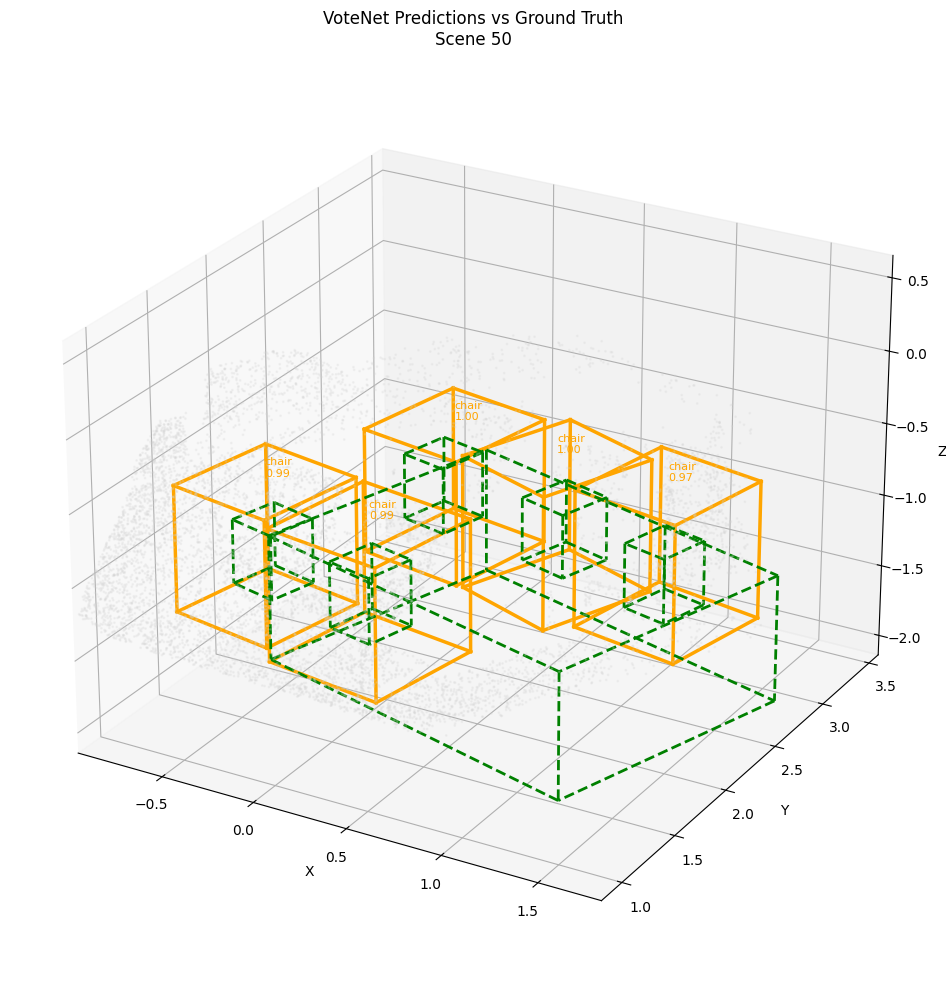

In [20]:
# ============================================
# Cell 5 — Visualization (Fixed)
# ============================================
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sunrgbd_utils import my_compute_box_3d

CLASS_COLORS = {
    0:'red',
    1:'cyan',
    2:'blue',
    3:'orange',
    4:'lime',
    5:'gold',
    6:'magenta',
    7:'purple',
    8:'brown',
    9:'pink'
}

BOX_EDGES = [
    (0,1),(1,2),(2,3),(3,0),
    (4,5),(5,6),(6,7),(7,4),
    (0,4),(1,5),(2,6),(3,7)
]

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(111, projection='3d')

# =====================================================
# Point cloud
# =====================================================
pc = sample['point_clouds'][:, :3]

N_VIZ = min(8000, len(pc))
idx = np.random.choice(len(pc), N_VIZ, replace=False)

pc_viz = pc[idx]

ax.scatter(
    pc_viz[:,0],
    pc_viz[:,1],
    pc_viz[:,2],
    c='lightgray',
    s=1,
    alpha=0.2
)

# =====================================================
# Predicted boxes
# =====================================================
for cls_idx, corners, score in detections:

    if score < 0.90:
        continue

    # VoteNet -> point cloud coordinates
    corners = np.column_stack([
        corners[:,0],
        corners[:,2],
        -corners[:,1]
    ])

    color = CLASS_COLORS[cls_idx]

    for i, j in BOX_EDGES:
        ax.plot(
            [corners[i,0], corners[j,0]],
            [corners[i,1], corners[j,1]],
            [corners[i,2], corners[j,2]],
            color=color,
            linewidth=2.5
        )

    center = corners.mean(axis=0)

    ax.text(
        center[0],
        center[1],
        corners[:,2].max()+0.03,
        f'{CLASS_NAMES[cls_idx]}\n{score:.2f}',
        fontsize=8,
        color=color
    )

# =====================================================
# Ground truth boxes
# =====================================================
gt_boxes = sample['max_gt_bboxes']
box_mask = sample['box_label_mask']

for i in range(len(gt_boxes)):

    if box_mask[i] == 0:
        continue

    gt = gt_boxes[i]

    center = gt[:3]
    size = gt[3:6]
    heading = gt[6]

    # IMPORTANT: use HALF dimensions
    gt_corners = my_compute_box_3d(
        center,
        size/2.0,
        heading
    )

    for a, b in BOX_EDGES:
        ax.plot(
            [gt_corners[a,0], gt_corners[b,0]],
            [gt_corners[a,1], gt_corners[b,1]],
            [gt_corners[a,2], gt_corners[b,2]],
            color='green',
            linestyle='--',
            linewidth=2
        )

# =====================================================
# Equal axis scaling
# =====================================================
max_range = np.array([
    pc[:,0].max()-pc[:,0].min(),
    pc[:,1].max()-pc[:,1].min(),
    pc[:,2].max()-pc[:,2].min()
]).max()

mid_x = (pc[:,0].max()+pc[:,0].min())*0.5
mid_y = (pc[:,1].max()+pc[:,1].min())*0.5
mid_z = (pc[:,2].max()+pc[:,2].min())*0.5

ax.set_xlim(mid_x-max_range/2, mid_x+max_range/2)
ax.set_ylim(mid_y-max_range/2, mid_y+max_range/2)
ax.set_zlim(mid_z-max_range/2, mid_z+max_range/2)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.view_init(elev=25, azim=-60)

plt.title(
    f"VoteNet Predictions vs Ground Truth\nScene {SCENE_IDX}"
)

plt.tight_layout()
plt.savefig(f'/kaggle/working/scene_{SCENE_IDX}_predictions.png', dpi=120, bbox_inches='tight')
plt.show()

## Full mAP evaluation

In [21]:
# ============================================
# Full mAP evaluation on val set
# ============================================
import time, json
import torch
from torch.utils.data import DataLoader
from ap_helper import APCalculator, parse_predictions, parse_groundtruths

CLASS_NAMES = ['bed', 'table', 'sofa', 'chair', 'toilet',
               'desk', 'dresser', 'night_stand', 'bookshelf', 'bathtub']
CLASS2TYPE = {i: n for i, n in enumerate(CLASS_NAMES)}

# Eval-mode config (per_class_proposal=True for official mAP)
CONFIG_DICT = {
    'remove_empty_box':  True,
    'use_3d_nms':        True,
    'nms_iou':           0.25,
    'use_old_type_nms':  False,
    'cls_nms':           True,
    'per_class_proposal':True,    # IMPORTANT for eval
    'conf_thresh':       0.05,
    'dataset_config':    SUNRGBD_CONFIG,
}

ap25 = APCalculator(ap_iou_thresh=0.25, class2type_map=CLASS2TYPE)
ap50 = APCalculator(ap_iou_thresh=0.50, class2type_map=CLASS2TYPE)

BATCH_SIZE = 8
loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                    num_workers=2, pin_memory=True, drop_last=False)

print(f'Evaluating on {len(val_ds)} val scenes ({len(loader)} batches)...')
print('Expected runtime: 5-10 min\n')

LABEL_KEYS = ['center_label', 'heading_class_label', 'heading_residual_label',
              'size_class_label', 'size_residual_label', 'sem_cls_label',
              'box_label_mask', 'vote_label', 'vote_label_mask']

t0 = time.time()
model.eval()
with torch.no_grad():
    for i, batch in enumerate(loader):
        batch_gpu = {k: v.to(device, non_blocking=True) if isinstance(v, torch.Tensor) else v
                     for k, v in batch.items()}
        end_points = model(batch_gpu)
        end_points['point_clouds'] = batch_gpu['point_clouds']
        for k in LABEL_KEYS:
            end_points[k] = batch_gpu[k]

        batch_pred = parse_predictions(end_points, CONFIG_DICT)
        batch_gt = parse_groundtruths(end_points, CONFIG_DICT)

        ap25.step(batch_pred, batch_gt)
        ap50.step(batch_pred, batch_gt)

        if (i + 1) % 25 == 0:
            elapsed = time.time() - t0
            eta = elapsed / (i+1) * (len(loader) - i - 1)
            print(f'  batch {i+1}/{len(loader)} ({100*(i+1)/len(loader):.0f}%)  '
                  f'elapsed {elapsed:.0f}s  eta {eta:.0f}s', flush=True)

print(f'\nInference complete in {(time.time()-t0)/60:.1f} min')

# Compute metrics
metrics25 = ap25.compute_metrics()
metrics50 = ap50.compute_metrics()

# Pretty per-class table
print('\n' + '=' * 60)
print(f"  {'Class':14s} {'AP@0.25':>10s} {'AP@0.50':>10s}")
print('=' * 60)
results = {'per_class': {}}
for cls in CLASS_NAMES:
    k = f'{cls} Average Precision'
    a25 = metrics25.get(k, 0.0)
    a50 = metrics50.get(k, 0.0)
    results['per_class'][cls] = {'AP25': a25, 'AP50': a50}
    print(f"  {cls:14s} {a25*100:9.2f}% {a50*100:9.2f}%")
print('-' * 60)

map25 = metrics25['mAP']
map50 = metrics50['mAP']
ar25 = metrics25.get('AR', 0.0)
ar50 = metrics50.get('AR', 0.0)

print(f"  {'mAP':14s} {map25*100:9.2f}% {map50*100:9.2f}%")
print(f"  {'AR':14s} {ar25*100:9.2f}% {ar50*100:9.2f}%")
print('=' * 60)

# Save to JSON for report
results['mAP25'] = map25
results['mAP50'] = map50
results['AR25'] = ar25
results['AR50'] = ar50
results['n_val_scenes'] = len(val_ds)

with open('/kaggle/working/votenet_mAP_results.json', 'w') as f:
    json.dump(results, f, indent=2)

# Comparison context
print('\nFor context:')
print(f'  VoteNet paper (180 epochs, full recipe):  mAP@0.25 = 57.7%, mAP@0.5 = 32.9%')
print(f'  Our model (100 epochs, domain_aug init):  mAP@0.25 = {map25*100:.1f}%, mAP@0.5 = {map50*100:.1f}%')
print(f'\nSaved: /kaggle/working/votenet_mAP_results.json')

Evaluating on 5050 val scenes (632 batches)...
Expected runtime: 5-10 min

  batch 25/632 (4%)  elapsed 80s  eta 1951s
  batch 50/632 (8%)  elapsed 165s  eta 1916s
  batch 75/632 (12%)  elapsed 247s  eta 1833s
  batch 100/632 (16%)  elapsed 337s  eta 1795s
  batch 125/632 (20%)  elapsed 434s  eta 1761s
  batch 150/632 (24%)  elapsed 530s  eta 1702s
  batch 175/632 (28%)  elapsed 606s  eta 1581s
  batch 200/632 (32%)  elapsed 689s  eta 1487s
  batch 225/632 (36%)  elapsed 774s  eta 1399s
  batch 250/632 (40%)  elapsed 864s  eta 1321s
  batch 275/632 (44%)  elapsed 955s  eta 1240s
  batch 300/632 (47%)  elapsed 1042s  eta 1153s
  batch 325/632 (51%)  elapsed 1140s  eta 1077s
  batch 350/632 (55%)  elapsed 1255s  eta 1011s
  batch 375/632 (59%)  elapsed 1343s  eta 920s
  batch 400/632 (63%)  elapsed 1429s  eta 829s
  batch 425/632 (67%)  elapsed 1525s  eta 743s
  batch 450/632 (71%)  elapsed 1618s  eta 655s
  batch 475/632 (75%)  elapsed 1709s  eta 565s
  batch 500/632 (79%)  elapsed 1802